# Pearson vs Spearman Correlation: When the Number Lies

This notebook uses small synthetic datasets so every number can still be checked by hand on a slide.

The whole idea in one sentence:

> **Pearson** measures how *straight* the relationship is (linear).
> **Spearman** measures how *consistent the direction* is (monotonic) — computed from **ranks**, not from the raw values.

When a relationship clearly exists but is **not a straight line**, or when there is **one bad data point**,
Pearson can report a misleading number while Spearman stays correct.

| Section | Content |
|---|---|
| 1. Two ways to measure | How Pearson and Spearman differ |
| 2. Case 1 | One data error turns Pearson **negative** |
| 3. The mechanism | Why ranks are immune to outliers |
| 4. Case 2 | Exponential growth: Pearson 0.75, Spearman 1.00 |
| 5. Log transform | Making Pearson honest again |
| 6. Case 3 | Spearman's blind spot — U-shaped relationships |
| 7. Heatmaps | Comparing whole correlation matrices at once |
| 8. Ordinal categories | A low Pearson with **no** outliers involved |
| 9. Summary | Which one to use, and when |

## 1. Two ways to measure a relationship

| | Pearson | Spearman |
|---|---|---|
| Computed from | raw values | **ranks** of the values |
| Detects | **linear** relationships (straight line) | **monotonic** relationships (always up / always down) |
| Sensitivity to outliers | very high | low |
| Data scale required | interval / ratio | ordinal is enough |

Spearman is literally **Pearson computed on the ranks**. That is the only mechanical difference between
them — and it explains every example below.

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

BLUE = '#3b6fd4'
RED  = '#d9534f'

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'grid.color': '#e6e6e6',
    'grid.linewidth': 0.8,
})

def correlations(x, y):
    """Return (pearson, spearman), already rounded."""
    return round(pearsonr(x, y)[0], 3), round(spearmanr(x, y)[0], 3)

## 2. Case 1 — one bad value flips the conclusion

The case: the relationship between **study hours per week** and **exam score** for 20 students.

The data starts out clean: the more they study, the higher they score.

In [73]:
df = pd.DataFrame({
    'student':     [f'S{i:02d}' for i in range(1, 21)],
    'study_hours': list(range(1, 21)),
    'exam_score':  [42, 45, 44, 51, 55, 53, 60, 63, 66, 64,
                    72, 75, 73, 80, 82, 85, 88, 86, 93, 95],
})
df.head(8)

,student,study_hours,exam_score
0,S01,1,42
1,S02,2,45
2,S03,3,44
3,S04,4,51
4,S05,5,55
5,S06,6,53
6,S07,7,60
7,S08,8,63


In [74]:
p_clean, s_clean = correlations(df['study_hours'], df['exam_score'])
print(f'Clean data  ->  Pearson: {p_clean:.3f}   Spearman: {s_clean:.3f}')

Clean data  ->  Pearson: 0.993   Spearman: 0.992


Both are close to 1.0. Nothing wrong so far.

Now something that happens in almost every real dataset: **one student misses the exam**, and the school
system records it as `-999` (an internal code meaning "no data"). That value makes it into the analysis
before anyone cleans it up.

In [75]:
df_error = df.copy()
df_error.loc[df_error['student'] == 'S16', 'exam_score'] = -999   # S16 missed the exam

df_error.loc[13:17]

,student,study_hours,exam_score
13,S14,14,80
14,S15,15,82
15,S16,16,-999
16,S17,17,88
17,S18,18,86


In [76]:
p_error, s_error = correlations(df_error['study_hours'], df_error['exam_score'])

results = pd.DataFrame({
    'Pearson':  [p_clean, p_error],
    'Spearman': [s_clean, s_error],
}, index=['Clean data', 'Data + 1 error (-999)'])
results

,Pearson,Spearman
Clean data,0.993,0.992
Data + 1 error (-999),-0.152,0.812


Look at the second row:

- **Pearson drops from 0.99 to a negative number.** Read at face value, the conclusion becomes
  *"the more you study, the worse you score"* — which is completely wrong.
- **Spearman stays above 0.8**, still reporting a strong positive relationship.

19 out of 20 students tell the same story, but **a single value** is enough to flip Pearson.

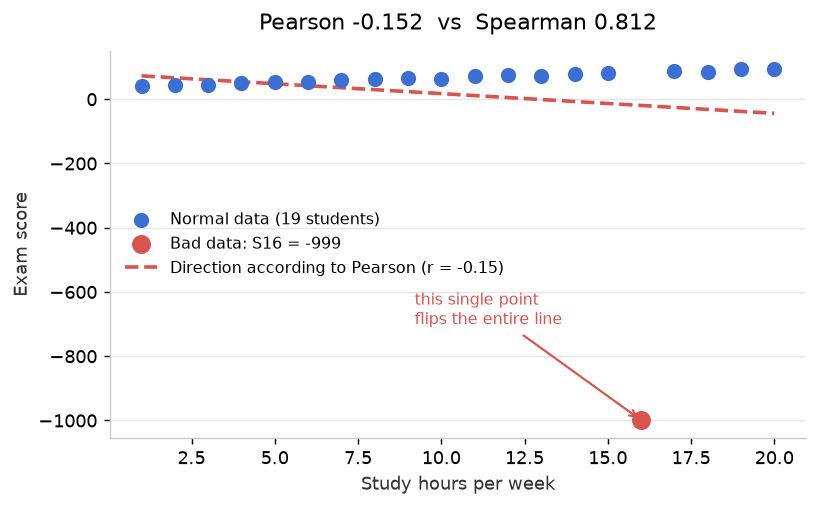

In [77]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))

normal = df_error[df_error['student'] != 'S16']
error  = df_error[df_error['student'] == 'S16']

ax.scatter(normal['study_hours'], normal['exam_score'],
           s=55, color=BLUE, zorder=3, label='Normal data (19 students)')
ax.scatter(error['study_hours'], error['exam_score'],
           s=90, color=RED, zorder=4, label='Bad data: S16 = -999')

# regression line = the direction Pearson "sees"
m, b = np.polyfit(df_error['study_hours'], df_error['exam_score'], 1)
xs = np.array([1, 20])
ax.plot(xs, m * xs + b, color=RED, ls='--', lw=2, zorder=2,
        label=f'Direction according to Pearson (r = {p_error:.2f})')

ax.annotate('this single point\nflips the entire line',
            xy=(16, -999), xytext=(9.2, -700),
            color=RED, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_xlabel('Study hours per week')
ax.set_ylabel('Exam score')
ax.set_title(f'Pearson {p_error:.3f}  vs  Spearman {s_error:.3f}', pad=12)
ax.grid(axis='y', zorder=0)
ax.legend(frameon=False, fontsize=9, loc='center left')
fig.tight_layout()
fig_case1 = fig

The y-axis stretches to -1000 because of one point. At that scale the other 19 points look flat — and
that is exactly how Pearson "sees" this data. One extreme value absorbs all the weight, because Pearson
works on **deviations from the mean**, and those deviations are squared.

## 3. The mechanism: why ranks are immune

Spearman never sees the number `-999`. All it sees is: **what rank is this value?** The answer is rank 1
(the lowest). It makes no difference whether the value is `-999`, `-9999`, or `0` — the rank is still 1.

In [78]:
ranks = pd.DataFrame({
    'student':     df_error['student'],
    'study_hours': df_error['study_hours'],
    'exam_score':  df_error['exam_score'],
    'rank_hours':  df_error['study_hours'].rank().astype(int),
    'rank_score':  df_error['exam_score'].rank().astype(int),
}).set_index('student')

ranks.loc[['S14', 'S15', 'S16', 'S17', 'S18']]

,study_hours,exam_score,rank_hours,rank_score
student,,,,
S14,14,80,14,15
S15,15,82,15,16
S16,16,-999,16,1
S17,17,88,17,18
S18,18,86,18,17


In [79]:
# Spearman = Pearson computed on the rank columns
check = pearsonr(ranks['rank_hours'], ranks['rank_score'])[0]
print(f'Pearson on the ranks : {check:.3f}')
print(f'Spearman directly    : {s_error:.3f}')

Pearson on the ranks : 0.812
Spearman directly    : 0.812


Identical. The `-999` that was thousands of points away from everything else becomes, once converted to
a rank, just "one step" below its neighbour. The outlier does not disappear — **its influence is
capped**.

## 4. Case 2 — a strong relationship that is not a straight line

The second case involves no bad data at all. The data is clean, and the relationship is **perfect**:
the number of active users of an app doubling every month.

Common sense says the correlation is 100%: it goes up every single month, without exception.

In [80]:
growth = pd.DataFrame({'month': range(1, 13)})
growth['active_users'] = 120 * 2 ** (growth['month'] - 1)
growth

,month,active_users
0,1,120
1,2,240
2,3,480
3,4,960
4,5,1920
5,6,3840
6,7,7680
7,8,15360
8,9,30720
9,10,61440


In [81]:
p_growth, s_growth = correlations(growth['month'], growth['active_users'])

growth_results = pd.DataFrame({
    'Pearson':  [p_growth],
    'Spearman': [s_growth],
}, index=['month vs active_users'])
growth_results

,Pearson,Spearman
month vs active_users,0.753,1.0


**Spearman = 1.000** — exactly what common sense says: the order increases perfectly, with no exception.

**Pearson = 0.753** — and this is the misleading number. Reported as-is, people will conclude "the
relationship is decent but not perfect, about 25% of it is unexplained". In reality the relationship is
deterministic: `users = 120 x 2^(month-1)`, with no noise whatsoever.

Pearson is not miscalculating. Pearson is answering a different question: *"how close are these points to
a straight line?"* And the answer genuinely is "not a straight line" — hence 0.753.

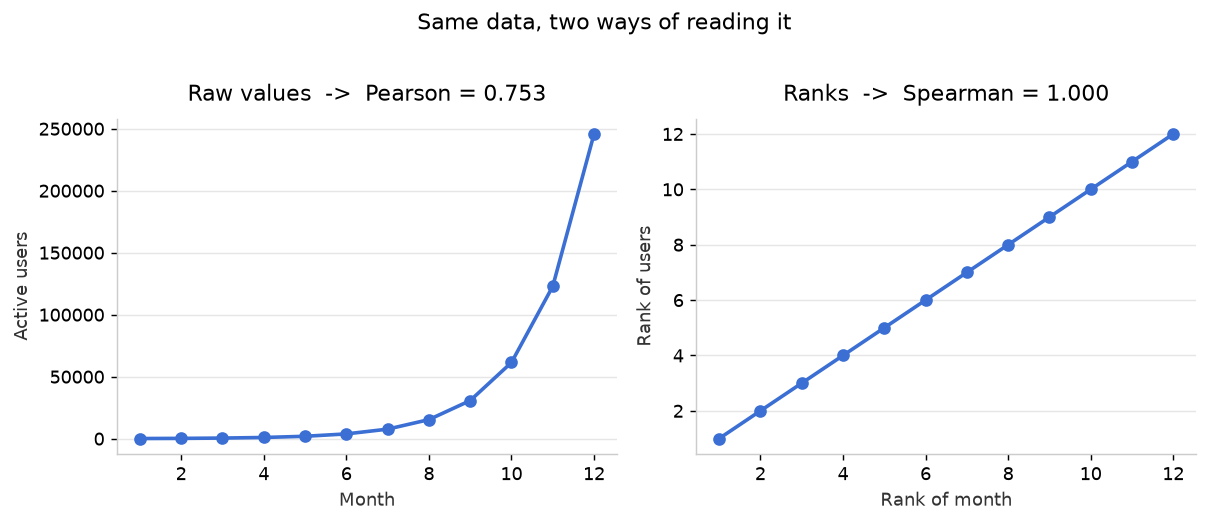

In [82]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.4, 3.9))

left.plot(growth['month'], growth['active_users'], color=BLUE, lw=2, marker='o', ms=6, zorder=3)
left.set_title(f'Raw values  ->  Pearson = {p_growth:.3f}', pad=10)
left.set_xlabel('Month')
left.set_ylabel('Active users')
left.grid(axis='y', zorder=0)

r_month = growth['month'].rank()
r_users = growth['active_users'].rank()
right.plot(r_month, r_users, color=BLUE, lw=2, marker='o', ms=6, zorder=3)
right.set_title(f'Ranks  ->  Spearman = {s_growth:.3f}', pad=10)
right.set_xlabel('Rank of month')
right.set_ylabel('Rank of users')
right.grid(axis='y', zorder=0)

fig.suptitle('Same data, two ways of reading it', y=1.02)
fig.tight_layout()
fig_case2 = fig

The left panel curves, so Pearson gives less than 1. The right panel is **perfectly straight** — that is
what Spearman measures, and that is what matches common sense.

## 5. If you still want Pearson: transform first

Since the only problem is "not straight", the shape can be straightened. For multiplicative growth, the
tool is the **logarithm**.

In [83]:
growth['log_users'] = np.log(growth['active_users'])

p_log, s_log = correlations(growth['month'], growth['log_users'])

comparison = pd.DataFrame({
    'Pearson':  [p_growth, p_log],
    'Spearman': [s_growth, s_log],
}, index=['month vs active_users', 'month vs log(active_users)'])
comparison

,Pearson,Spearman
month vs active_users,0.753,1.0
month vs log(active_users),1.000,1.0


After the log, Pearson rises to 1.000. Two things worth noting:

1. **Spearman does not change** (still 1.000). A log is a monotonic function, and monotonic functions do
   not change ranks — so Spearman is immune to this kind of transformation.
2. This is also why features such as price, income, or view counts are so often log-transformed before
   being fed into a linear model.

## 6. Case 3 — Spearman's blind spot

Spearman is not a universal replacement. It only wins for **monotonic** relationships. If the relationship
goes up and then down, both measures are blind.

The case: storage temperature vs product quality. There is an optimal temperature in the middle; too cold
or too hot both cause damage.

In [84]:
temp = pd.DataFrame({'temperature_c': range(-10, 11)})
temp['quality_score'] = 100 - 0.8 * temp['temperature_c'] ** 2

p_u, s_u = correlations(temp['temperature_c'], temp['quality_score'])
print(f'Pearson: {p_u:.3f}   Spearman: {s_u:.3f}')

Pearson: 0.000   Spearman: 0.000


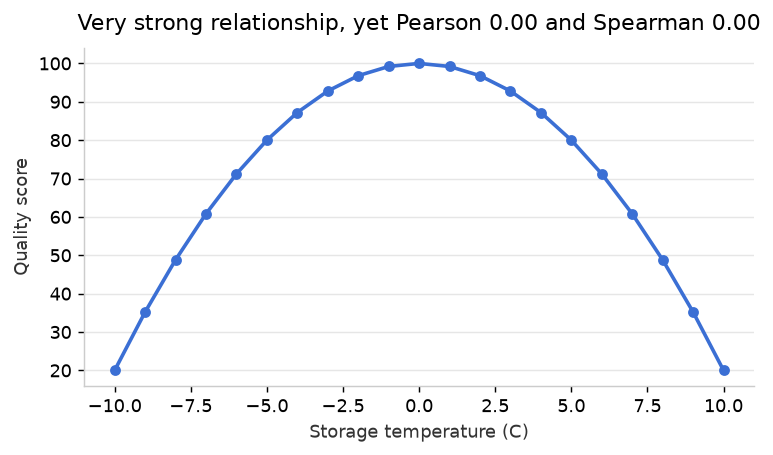

In [85]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(temp['temperature_c'], temp['quality_score'], color=BLUE, lw=2, marker='o', ms=5, zorder=3)
ax.set_xlabel('Storage temperature (C)')
ax.set_ylabel('Quality score')
ax.set_title(f'Very strong relationship, yet Pearson {p_u:.2f} and Spearman {s_u:.2f}', pad=10)
ax.grid(axis='y', zorder=0)
fig.tight_layout()
fig_case3 = fig

The relationship is obvious and deterministic, yet **both correlations are near zero**. The lesson: a low
correlation does not mean "no relationship" — sometimes it only means "the relationship is not the kind
this tool measures".

Which is why: **always plot a scatter before trusting a correlation number.**

## 7. Heatmaps: seeing the whole matrix at once

So far we compared two columns at a time. Real datasets have dozens of columns, and checking every pair by
hand is not practical. A **correlation heatmap** compresses all of it into one picture.

A useful trick: build the heatmap **twice** (Pearson and Spearman), then look at the **difference**. The
cells that light up in the difference heatmap are exactly the column pairs that need a manual check.

### 7.1 A dataset with several columns

The same 20 students, plus three more columns — each one deliberately representing one case from the
earlier sections.

| Column | Relationship with `study_hours` |
|---|---|
| `exam_score` | increasing, but contains **1 bad value** (`-999`) |
| `practice_problems` | increasing **exponentially** (curved, no bad data) |
| `gaming_hours` | decreasing, **curved** (more studying, less gaming) |
| `sleep_hours` | unrelated (control column) |

In [86]:
multi = pd.DataFrame({
    'study_hours':       range(1, 21),
    'exam_score':        df_error['exam_score'].values,          # contains -999
    'practice_problems': [round(4 * 1.3 ** i) for i in range(20)],
    'gaming_hours':      [round(60 / (0.35 * i + 1), 1) for i in range(20)],
    'sleep_hours':       [7, 6, 8, 7, 7, 6, 8, 7, 6, 7,
                          8, 6, 7, 7, 8, 6, 7, 8, 6, 7],
})
multi.head(6)

,study_hours,exam_score,practice_problems,gaming_hours,sleep_hours
0,1,42,4,60.0,7
1,2,45,5,44.4,6
2,3,44,7,35.3,8
3,4,51,9,29.3,7
4,5,55,11,25.0,7
5,6,53,15,21.8,6


In [87]:
corr_pearson  = multi.corr(method='pearson').round(3)
corr_spearman = multi.corr(method='spearman').round(3)
difference    = (corr_spearman - corr_pearson).round(3)

corr_pearson

,study_hours,exam_score,practice_problems,gaming_hours,sleep_hours
study_hours,1.000,-0.152,0.850,-0.856,0.006
exam_score,-0.152,1.000,-0.055,0.107,0.297
practice_problems,0.850,-0.055,1.000,-0.549,-0.029
gaming_hours,-0.856,0.107,-0.549,1.000,-0.031
sleep_hours,0.006,0.297,-0.029,-0.031,1.000


### 7.2 The heatmap function

A few rules applied here, because they change how people read the picture:

- **A diverging color scale** (red - neutral - blue) with **0 exactly at the midpoint**. Correlation has a
  direction, so the color must distinguish positive from negative — not just "light to dark".
- **The range is locked to -1 … 1** for both heatmaps, so the colors can be compared directly.
- **The number is printed in every cell**, so nothing depends on color alone.

In [88]:
from matplotlib.colors import LinearSegmentedColormap

# red = negative, neutral = zero, blue = positive
CMAP = LinearSegmentedColormap.from_list('correlation', [RED, '#f2f2f0', BLUE])

def heatmap(ax, matrix, title, vmin=-1, vmax=1, cmap=CMAP, label_y=True):
    im = ax.imshow(matrix.values, cmap=cmap, vmin=vmin, vmax=vmax)
    label = matrix.columns

    ax.set_xticks(range(len(label)), label, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(label)), label if label_y else [''] * len(label), fontsize=9)
    ax.set_title(title, pad=12)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)

    # thin separators between cells
    ax.set_xticks(np.arange(len(label) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(label) + 1) - 0.5, minor=True)
    ax.tick_params(which='minor', length=0)
    ax.grid(which='minor', color='white', linewidth=2)

    limit = max(abs(vmin), abs(vmax))
    for i in range(len(label)):
        for j in range(len(label)):
            value = matrix.values[i, j]
            color = 'white' if abs(value) > 0.55 * limit else '#333333'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                    color=color, fontsize=9)
    return im

### 7.3 Pearson vs Spearman side by side

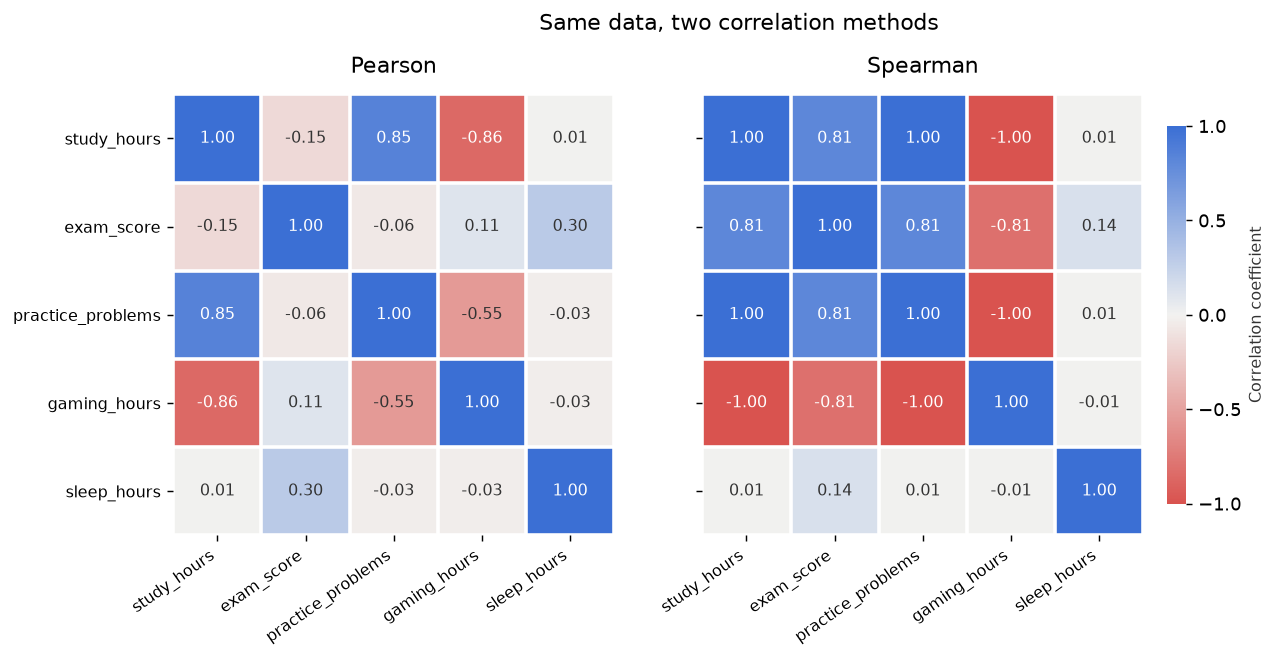

In [89]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.6, 4.6))

heatmap(left, corr_pearson, 'Pearson')
im = heatmap(right, corr_spearman, 'Spearman', label_y=False)  # symmetric matrix, left labels are enough

cbar = fig.colorbar(im, ax=[left, right], shrink=0.82, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.set_label('Correlation coefficient', fontsize=9)

fig.suptitle('Same data, two correlation methods', y=1.0)
fig_heatmap = fig

The `exam_score` row is the striking one: **almost white (near zero) in the Pearson heatmap**, but
**strongly blue in the Spearman heatmap**. If feature selection were done by reading the Pearson heatmap
alone, `exam_score` would be judged uninformative and possibly dropped — even though it is one of the
strongest columns, with only a single bad row.

Note `practice_problems` and `gaming_hours` too: Spearman reports **exactly 1.000 and -1.000** (those
relationships really are deterministic and monotonic), while Pearson only reaches 0.850 and -0.856
because the shapes are curved.

### 7.4 The difference heatmap — where the decision is made

This heatmap shows **Spearman minus Pearson**. A colored cell means the two methods disagree about that
pair of columns, and that is the shortlist of scatter plots worth looking at.

The color range is locked to -1 … 1 (the same as the two heatmaps above) so the size of the difference is
not visually exaggerated.

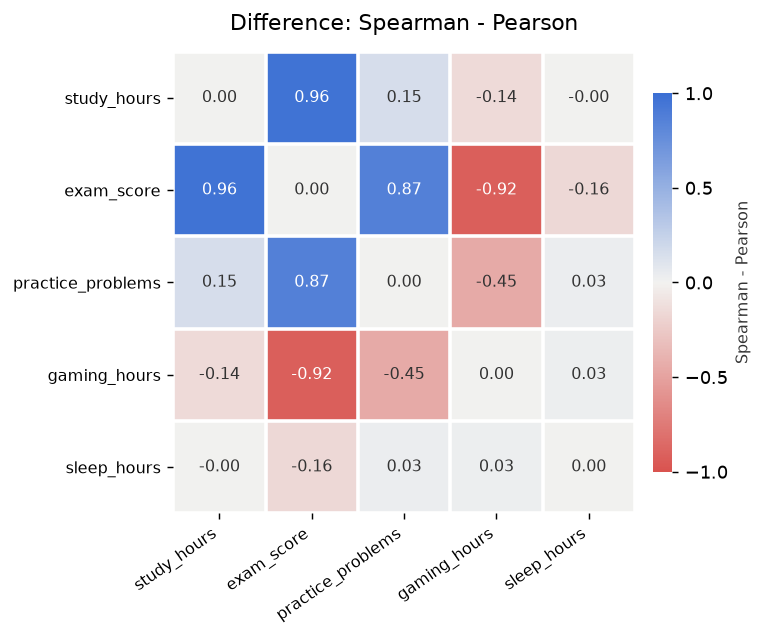

In [90]:
fig, ax = plt.subplots(figsize=(6.2, 5.0))

im = heatmap(ax, difference, 'Difference: Spearman - Pearson')

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.03, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.set_label('Spearman - Pearson', fontsize=9)

fig.tight_layout()
fig_difference = fig

How to read it:

- **Neutral cells (close to 0)** -> the two methods agree. The relationship really is close to linear;
  no further checking needed. Every `sleep_hours` pair falls here.
- **Blue cells (Spearman much higher)** -> there is a monotonic relationship Pearson cannot see. The cause
  is either an outlier or curvature.
- **Red cells (Pearson much higher)** -> be careful. This usually means the correlation is **created by a
  few extreme points** rather than by the bulk of the data.

### 7.5 Ranking the pairs worth checking

Reading a heatmap by eye is still subjective. For a dataset with many columns, just sort the differences
and take the top ones.

In [91]:
# keep the upper triangle only, so each pair is counted once
pairs = (
    difference.where(np.triu(np.ones(difference.shape), k=1).astype(bool))
    .stack()
    .rename('difference')
    .reset_index()
    .rename(columns={'level_0': 'column_A', 'level_1': 'column_B'})
)

pairs['pearson']  = [corr_pearson.loc[a, b]  for a, b in zip(pairs['column_A'], pairs['column_B'])]
pairs['spearman'] = [corr_spearman.loc[a, b] for a, b in zip(pairs['column_A'], pairs['column_B'])]
pairs['abs_diff'] = pairs['difference'].abs()

to_check = (pairs
            .sort_values('abs_diff', ascending=False)
            [['column_A', 'column_B', 'pearson', 'spearman', 'difference']]
            .head(5)
            .reset_index(drop=True))
to_check

,column_A,column_B,pearson,spearman,difference
0,study_hours,exam_score,-0.152,0.812,0.964
1,exam_score,gaming_hours,0.107,-0.812,-0.919
2,exam_score,practice_problems,-0.055,0.812,0.867
3,practice_problems,gaming_hours,-0.549,-1.000,-0.451
4,exam_score,sleep_hours,0.297,0.136,-0.161


All three top pairs involve `exam_score` — the column containing `-999`. The difference heatmap pointed
straight at the source of the problem without us needing to know in advance that a bad value was in there.

A practical threshold: **a difference above 0.1 is worth checking**, and above 0.2 there is almost
certainly an outlier or a non-linear relationship.

## 8. Ordinal categories — a low Pearson with no outliers at all

Every example so far had an obvious culprit: a `-999`, or a curve that shoots off the top of the chart.
This section has **neither**. The data is clean, every value is plausible, and no point sits far from its
neighbours — and Pearson still understates the relationship badly.

The cause is an assumption built into Pearson that is easy to miss:

> Pearson assumes the **gap between category 1 and 2 is the same size as the gap between category 5 and 6.**

Ordinal categories almost never work that way. The codes are evenly spaced because we *wrote* them that
way; reality is not obliged to match.

### 8.1 The dataset: customer membership tiers

60 customers across six membership tiers. The tier is an ordinal category encoded the obvious way
(`Free` = 1 … `Diamond` = 6), and a realistic customer base is a pyramid — many on Free, few on Diamond.

Notice the spend column: the step from `Free` to `Basic` is about 5 dollars, but the step from `Platinum`
to `Diamond` is about 690 dollars. Same "one tier" difference in the code, wildly different in reality.

In [92]:
rng = np.random.default_rng(7)

tier_map = pd.DataFrame({
    'tier':            ['Free', 'Basic', 'Silver', 'Gold', 'Platinum', 'Diamond'],
    'tier_code':       [1, 2, 3, 4, 5, 6],
    'customers':       [20, 14, 10, 7, 5, 4],
    'typical_spend':   [3, 8, 22, 65, 210, 900],
    'typical_tickets': [12, 9, 6, 4, 2, 1],
    'satisfaction':    [1, 2, 3, 4, 4, 5],
})
tier_map

,tier,tier_code,customers,typical_spend,typical_tickets,satisfaction
0,Free,1,20,3,12,1
1,Basic,2,14,8,9,2
2,Silver,3,10,22,6,3
3,Gold,4,7,65,4,4
4,Platinum,5,5,210,2,4
5,Diamond,6,4,900,1,5


In [93]:
rows = []
for t in tier_map.itertuples():
    for _ in range(t.customers):
        rows.append({
            'tier':            t.tier,
            'tier_code':       t.tier_code,
            'monthly_spend':   round(t.typical_spend * rng.uniform(0.9, 1.1), 1),
            'support_tickets': max(0, int(t.typical_tickets + rng.integers(-1, 2))),
            'satisfaction':    t.satisfaction,
        })

customers = pd.DataFrame(rows)
customers['account_age_months'] = rng.integers(1, 48, len(customers))   # control column, unrelated

print(f'{len(customers)} customers')
customers.head(6)

60 customers


,tier,tier_code,monthly_spend,support_tickets,satisfaction,account_age_months
0,Free,1,3.1,13,1,34
1,Free,1,3.2,13,1,2
2,Free,1,2.8,11,1,46
3,Free,1,3.2,11,1,42
4,Free,1,2.7,12,1,27
5,Free,1,3.2,13,1,22


In [94]:
customers

,tier,tier_code,monthly_spend,support_tickets,satisfaction,account_age_months
0,Free,1,3.1,13,1,34
1,Free,1,3.2,13,1,2
2,Free,1,2.8,11,1,46
3,Free,1,3.2,11,1,42
4,Free,1,2.7,12,1,27
5,Free,1,3.2,13,1,22
6,Free,1,3.0,13,1,36
7,Free,1,2.9,11,1,26
8,Free,1,2.9,13,1,23
9,Free,1,3.0,12,1,16


### 8.2 Confirming there are no outliers

Before blaming Pearson, rule out the explanation from Case 1. Each tier should be a tight cluster, and the
clusters must not overlap — no stray value, nothing to clean.

In [95]:
spread = customers.groupby('tier_code')['monthly_spend'].agg(['min', 'max', 'count'])
spread['spread_vs_typical'] = (spread['max'] / spread['min']).round(2)
spread

,min,max,count,spread_vs_typical
tier_code,,,,
1,2.7,3.3,20,1.22
2,7.2,8.6,14,1.19
3,20.5,23.4,10,1.14
4,60.2,71.1,7,1.18
5,196.6,228.0,5,1.16
6,853.1,969.1,4,1.14


Every tier spans about 1.2x from its own minimum to its own maximum, and no tier's range touches the
next tier's range. There is no outlier here by any definition — just six tight, well-separated groups.

Whatever Pearson is about to do, it is **not** an outlier problem.

### 8.3 The correlation matrices

In [96]:
NUM = ['tier_code', 'monthly_spend', 'support_tickets', 'satisfaction', 'account_age_months']

cust_pearson    = customers[NUM].corr(method='pearson').round(3)
cust_spearman   = customers[NUM].corr(method='spearman').round(3)
cust_difference = (cust_spearman - cust_pearson).round(3)

p_tier, s_tier = correlations(customers['tier_code'], customers['monthly_spend'])
print(f'tier_code vs monthly_spend  ->  Pearson: {p_tier:.3f}   Spearman: {s_tier:.3f}')

tier_code vs monthly_spend  ->  Pearson: 0.736   Spearman: 0.972


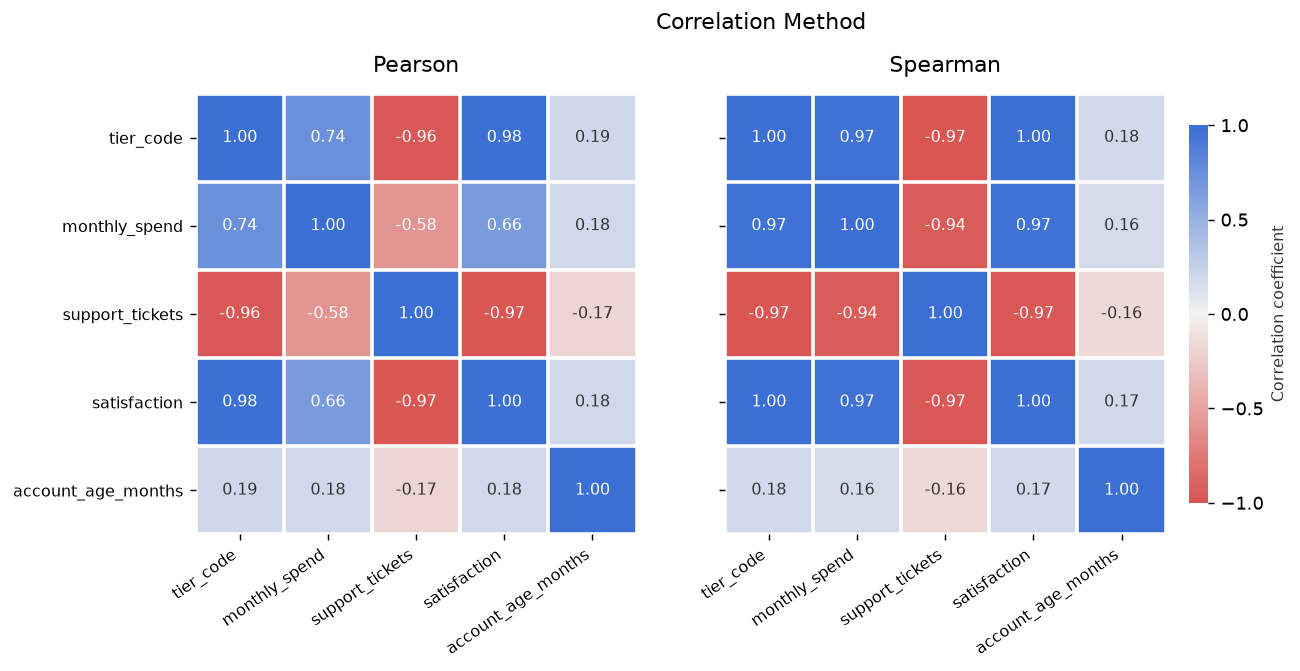

In [97]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.6, 4.6))

heatmap(left, cust_pearson, 'Pearson')
im = heatmap(right, cust_spearman, 'Spearman', label_y=False)

cbar = fig.colorbar(im, ax=[left, right], shrink=0.82, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.set_label('Correlation coefficient', fontsize=9)

fig.suptitle('Correlation Method', y=1.0)
fig_cat_heatmap = fig

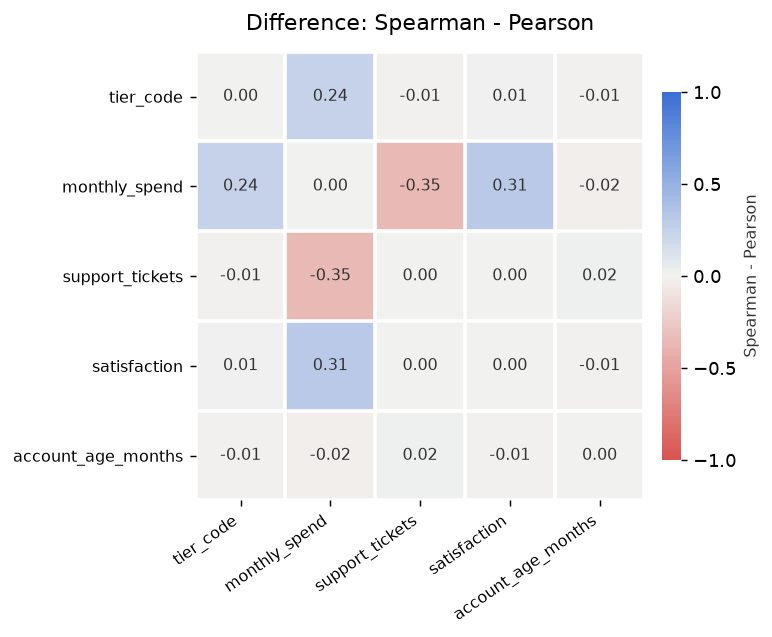

In [98]:
fig, ax = plt.subplots(figsize=(6.2, 5.0))

im = heatmap(ax, cust_difference, 'Difference: Spearman - Pearson')

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.03, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.set_label('Spearman - Pearson', fontsize=9)

fig.tight_layout()
fig_cat_difference = fig

The difference heatmap has a very specific shape: **only the `monthly_spend` row and column light up.**

| Pair | Pearson | Spearman | Reading |
|---|---|---|---|
| `tier_code` - `monthly_spend` | **0.736** | **0.972** | "moderate" vs "almost perfect" |
| `monthly_spend` - `support_tickets` | **-0.583** | **-0.936** | "moderate" vs "very strong" |
| `monthly_spend` - `satisfaction` | **0.661** | **0.969** | "moderate" vs "almost perfect" |
| `tier_code` - `satisfaction` | 0.985 | 0.997 | both agree |
| `tier_code` - `support_tickets` | -0.962 | -0.971 | both agree |
| anything - `account_age_months` | ~0.18 | ~0.17 | both agree (control) |

This is the useful part of the diagnosis. `tier_code`, `satisfaction`, and `support_tickets` are all
ordinal or count columns, and Pearson handles them fine — their **real** steps happen to be roughly evenly
spaced. `monthly_spend` is the only column that lives on a **multiplicative** scale, where each tier is
roughly 3x the previous one rather than a fixed amount higher.

So the problem is not "categorical data" in general. It is the mismatch between **evenly spaced codes** and
**unevenly spaced reality** — and the difference heatmap points at exactly the column responsible.

### 8.4 Seeing it directly

The scatter below is the same relationship in two forms. A small horizontal jitter is added so that
overlapping customers in the same tier stay visible.

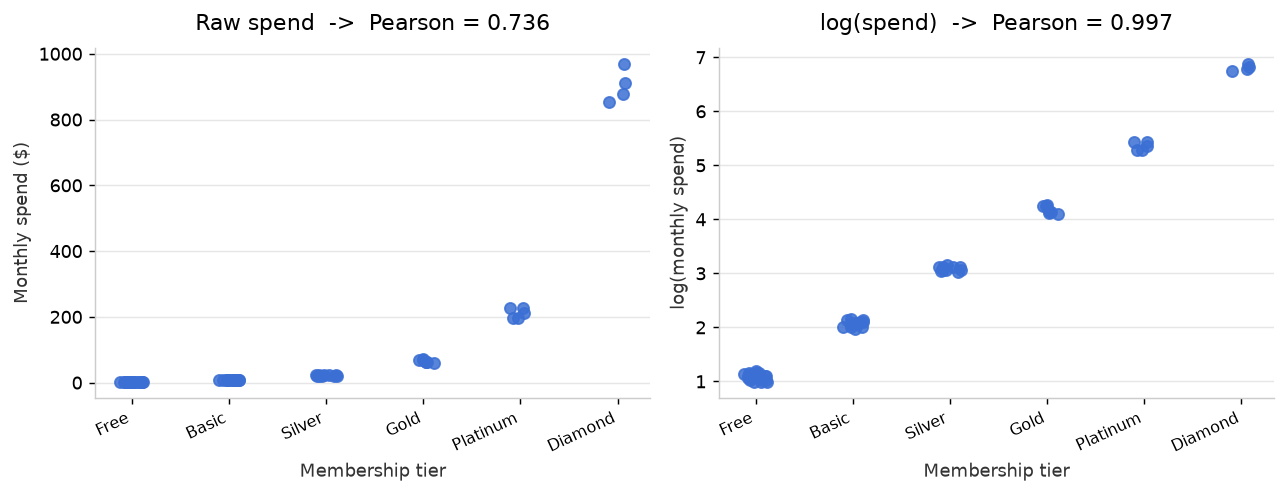

In [99]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 3.9))

jitter = rng.uniform(-0.12, 0.12, len(customers))

left.scatter(customers['tier_code'] + jitter, customers['monthly_spend'],
             s=38, color=BLUE, alpha=0.85, zorder=3)
left.set_title(f'Raw spend  ->  Pearson = {p_tier:.3f}', pad=10)
left.set_ylabel('Monthly spend ($)')

right.scatter(customers['tier_code'] + jitter, np.log(customers['monthly_spend']),
              s=38, color=BLUE, alpha=0.85, zorder=3)
p_log_spend = round(pearsonr(customers['tier_code'], np.log(customers['monthly_spend']))[0], 3)
right.set_title(f'log(spend)  ->  Pearson = {p_log_spend:.3f}', pad=10)
right.set_ylabel('log(monthly spend)')

for ax in (left, right):
    ax.set_xlabel('Membership tier')
    ax.set_xticks(tier_map['tier_code'], tier_map['tier'], rotation=25, ha='right', fontsize=9)
    ax.grid(axis='y', zorder=0)

fig.tight_layout()
fig_cat_scatter = fig

On the left, the first four tiers are squashed into a band near zero — not because those customers are
unimportant, but because the Diamond tier stretches the axis. Pearson is fitting a straight line through
that shape, and a straight line simply cannot pass near all six clusters at once.

On the right, the same data on a log scale falls almost exactly on a line: **Pearson recovers to 0.997**,
matching what Spearman said all along.

Note that all six clusters are still tight and evenly separated on the right — further confirmation that
nothing here was ever an outlier. Only the *spacing* was the problem.

### 8.5 What to do about it

Three options, in order of how often they are the right call:

1. **Use Spearman to screen ordinal features.** Costs nothing, and it will not mistake "unevenly spaced"
   for "unrelated".
2. **Transform the skewed column** (`log`, `sqrt`) so the spacing matches the codes. This is what makes
   Pearson usable again, and it is the same fix as Section 5.
3. **Encode the category by its real value instead of its rank** — replace `tier_code` with the tier's
   typical spend, or use target encoding. The category stops being evenly spaced by construction.

The failure mode to avoid: running a Pearson heatmap over a dataset full of ordinal features, seeing a
column at 0.7 where others sit at 0.96, and quietly dropping it during feature selection.

## 9. Summary

In [100]:
summary = pd.DataFrame({
    'Case': ['Linear relationship, clean data',
             'Outlier / bad data present',
             'Monotonic but curved (exponential)',
             'Non-monotonic (U-shaped)',
             'Ordinal category, unevenly spaced (no outliers)'],
    'Pearson': [f'{p_clean:.2f} (correct)',
                f'{p_error:.2f} (MISLEADING)',
                f'{p_growth:.2f} (too low)',
                f'{p_u:.2f} (blind)',
                f'{p_tier:.2f} (too low)'],
    'Spearman': [f'{s_clean:.2f} (correct)',
                 f'{s_error:.2f} (correct)',
                 f'{s_growth:.2f} (correct)',
                 f'{s_u:.2f} (blind)',
                 f'{s_tier:.2f} (correct)'],
}).set_index('Case')
summary

,Pearson,Spearman
Case,,
"Linear relationship, clean data",0.99 (correct),0.99 (correct)
Outlier / bad data present,-0.15 (MISLEADING),0.81 (correct)
Monotonic but curved (exponential),0.75 (too low),1.00 (correct)
Non-monotonic (U-shaped),0.00 (blind),0.00 (blind)
"Ordinal category, unevenly spaced (no outliers)",0.74 (too low),0.97 (correct)


**Practical guidance**

| Situation | Use |
|---|---|
| Numeric data, relationship believed linear, no extreme outliers | Pearson |
| Outliers present, or a heavily skewed distribution (price, income, views) | Spearman |
| Ordinal data (1-5 ratings, education level, rankings) | Spearman |
| Category codes whose real-world steps are uneven (tiers, brackets) | Spearman |
| You do not yet know the shape of the relationship | **Compute both and compare** |

How to read the gap between them:

- **Pearson ~ Spearman** -> the relationship really is close to linear.
- **Spearman >> Pearson** -> a strong but curved relationship, or an outlier. Check the scatter plot;
  consider a transformation (log/sqrt) or cleaning the outlier.
- **Pearson >> Spearman** -> usually the opposite problem: a few extreme points are **creating** a fake
  correlation while the bulk of the data is unrelated.
- **Both ~ 0** -> not necessarily "no relationship". Plot it first.

```python
df[['study_hours', 'exam_score']].corr(method='pearson')
df[['study_hours', 'exam_score']].corr(method='spearman')
```

In [101]:
# The short version: one matrix per method
columns = ['study_hours', 'exam_score']
matrices = pd.concat(
    {'pearson':  df_error[columns].corr(method='pearson'),
     'spearman': df_error[columns].corr(method='spearman')}
).round(3)
matrices

study_hours  exam_score
pearson  study_hours        1.000      -0.152
         exam_score        -0.152       1.000
spearman study_hours        1.000       0.812
         exam_score         0.812       1.000

## Export tables & charts to PNG for slides

Run the cell below if the tables and charts are going to be used as images in PowerPoint.

In [102]:
import dataframe_image as dfi

dfi.export(df.head(8),    'correlation_data_original.png',    table_conversion='matplotlib', dpi=200)
dfi.export(results,       'correlation_case1_results.png',    table_conversion='matplotlib', dpi=200)
dfi.export(ranks.loc[['S14', 'S15', 'S16', 'S17', 'S18']],
                          'correlation_ranks.png',            table_conversion='matplotlib', dpi=200)
dfi.export(growth,        'correlation_case2_data.png',       table_conversion='matplotlib', dpi=200)
dfi.export(comparison,    'correlation_log_transform.png',    table_conversion='matplotlib', dpi=200)
dfi.export(summary,       'correlation_summary.png',          table_conversion='matplotlib', dpi=200)
dfi.export(corr_pearson,  'correlation_matrix_pearson.png',   table_conversion='matplotlib', dpi=200)
dfi.export(corr_spearman, 'correlation_matrix_spearman.png',  table_conversion='matplotlib', dpi=200)
dfi.export(to_check,      'correlation_pairs_to_check.png',   table_conversion='matplotlib', dpi=200)
dfi.export(tier_map,      'correlation_tier_map.png',         table_conversion='matplotlib', dpi=200)
dfi.export(spread,        'correlation_tier_spread.png',      table_conversion='matplotlib', dpi=200)
dfi.export(cust_pearson,  'correlation_cat_matrix_pearson.png',  table_conversion='matplotlib', dpi=200)
dfi.export(cust_spearman, 'correlation_cat_matrix_spearman.png', table_conversion='matplotlib', dpi=200)

fig_case1.savefig('correlation_case1_plot.png', dpi=200, bbox_inches='tight')
fig_case2.savefig('correlation_case2_plot.png', dpi=200, bbox_inches='tight')
fig_case3.savefig('correlation_case3_plot.png', dpi=200, bbox_inches='tight')
fig_heatmap.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
fig_difference.savefig('correlation_heatmap_difference.png', dpi=200, bbox_inches='tight')
fig_cat_heatmap.savefig('correlation_cat_heatmap.png', dpi=200, bbox_inches='tight')
fig_cat_difference.savefig('correlation_cat_heatmap_difference.png', dpi=200, bbox_inches='tight')
fig_cat_scatter.savefig('correlation_cat_scatter.png', dpi=200, bbox_inches='tight')